##TASK 3: Car Price Prediction with Machine Learning
###● Collect car-related features like brand goodwill, horsepower, mileage, etc.
###● Train a regression model to predict car prices based on these features.
###● Handle data preprocessing, feature engineering, and model evaluation
###● Use Python libraries like Pandas, Scikit-learn and Matplotlib for the workflow.
###● Understand real-world applications of machine learning in price prediction.


#link with google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Import Libraries && load dataset

In [3]:
import pandas as pd

# مسار الملف الخاص بك في الدرايف
file_path = '/content/drive/MyDrive/CodeAlpha_Internship/Dataset/car data.csv'

# قراءة الملف
df = pd.read_csv(file_path)

# عرض أول 5 أسطر من البيانات
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


#EDA - Exploratory Data Analysis

In [4]:
# معرفة عدد الصفوف والأعمدة
df.shape

(301, 9)

##الخطوة 2: معرفة أنواع البيانات والتأكد من عدم وجود قيم مفقودة
##Missing Values

In [5]:
# عرض معلومات تفصيلية عن البيانات
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


##الخطوة 3: نظرة إحصائية سريعة على الأرقام

In [6]:
# ملخص إحصائي للأعمدة الرقمية
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


#رؤية العلاقات بين البيانات (Visualizing Data)
###💡 ماذا سنستفيد من هذا الكود؟
الرسمة الأولى (Scatter Plot) ستوضح لك هل الأسعار ترتفع مع الموديلات الأحدث أم لا،

 ##والرسمة الثانية (Box Plot) ستكشف لك من هو الوقود المهيمن والأعلى سعراً في السوق الخاص بهذه البيانات.

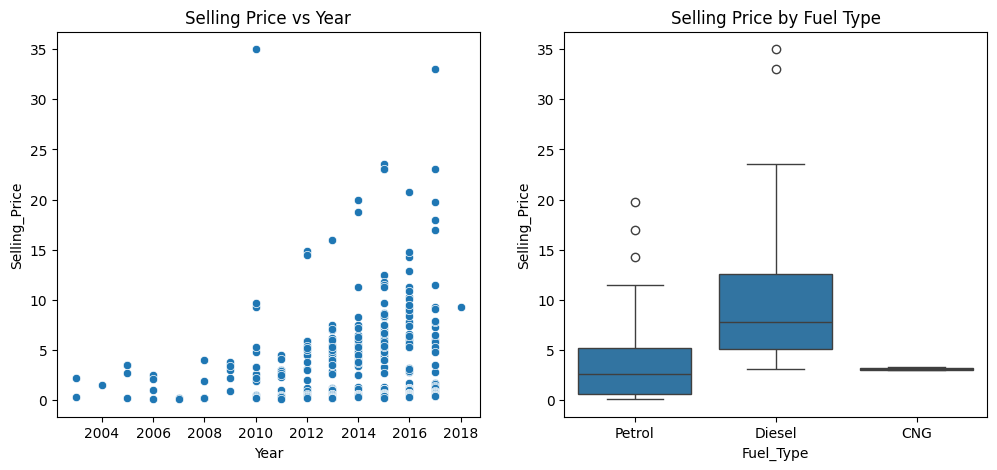

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# تجهيز مساحة الرسم
plt.figure(figsize=(12, 5))

# الرسمة الأولى: العلاقة بين سنة الصنع وسعر البيع
plt.subplot(1, 2, 1)
sns.scatterplot(x='Year', y='Selling_Price', data=df)
plt.title('Selling Price vs Year')

# الرسمة الثانية: مقارنة أسعار البيع بناءً على نوع الوقود (بنزين ضد ديزل)
plt.subplot(1, 2, 2)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Selling Price by Fuel Type')

plt.show()

# المرحلة الثالثة: تنظيف وتجهيز البيانات (Data Preprocessing).

###🛠️ المرحلة الثالثة: تنظيف وتجهيز البيانات في هذه المرحلة، سنقوم بتهيئة البيانات وتجهيزها لتصبح صالحة لتدريب نموذج الذكاء الاصطناعي لاحقاً.
### الذكاء الاصطناعي لا يفهم الكلمات النصية (مثل Petrol, Dealer, Manual)، بل يفهم الأرقام فقط ($0, 1, 2$). كما أن هناك قيمة ذكية يمكننا حسابها وهي "عمر السيارة" بدلاً من "سنة الصنع".سنقوم بالخطوات التالية خطوة بخطوة:

###الخطوة 1: حساب عمر السيارة (Car Age)
###بدلاً من ترك سنة الصنع (مثل 2014)، يفضل حساب عمر السيارة بطرح سنة الصنع من السنة الحالية (بما أننا في عام 2026، سنطرح سنة الصنع من 2026 لمعرفة كم سنة مرت على السيارة). هذا يجعل الموديل الرياضي يفهم تأثير الزمن بشكل أفضل. ومن ثم سنحذف عمود Year القديم وعمود Car_Name (لأن اسم السيارة الفرعي هنا لن يساعدنا كثيراً في التوقع البسيط).

In [8]:
# حساب عمر السيارة بناءً على العام الحالي 2026
df['Car_Age'] = 2026 - df['Year']

# حذف الأعمدة التي لم نعد بحاجتها
df = df.drop(['Car_Name', 'Year'], axis=1)

# عرض البيانات للتأكد من التغيير
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


##الخطوة 2: تحويل الكلمات إلى أرقام (Encoding Categorical Data)

###لدينا 3 أعمدة تحتوي على نصوص: Fuel_Type و Selling_type و Transmission.
###سنستخدم دالة ذكية جداً في بايثون تسمى pd.get_dummies(). هذه الدالة تقوم بتحويل الكلمات إلى أعمدة تحتوي على $0$ أو $1$ تلقائياً (تُسمى One-Hot Encoding).

In [9]:
# تحويل الأعمدة النصية إلى أرقام (0 و 1)
df_ready = pd.get_dummies(df, drop_first=True)

# عرض البيانات بعد التحويل لرؤية النتيجة الاحترافية
df_ready.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


### ماذا سيحدث بعد تنفيذ الخطوة 2؟ستلاحظ أن عمود Fuel_Type قد تحول مثلاً إلى Fuel_Type_Diesel و Fuel_Type_Petrol بقيم $0$ أو $1$. الآن أصبح الجدول كاملاً عبارة عن أرقام فقط وجاهز تماماً ليدخل إلى مختبر الذكاء الاصطناعي!طبق هذين الكودين يا صديقي، وأخبرني بشكل الجدول الجديد (df_ready.head) عندما يظهر لك، لكي ننتقل فوراً إلى المرحلة الرابعة: تقسيم البيانات وبناء نموذج الذكاء الاصطناعي!

##🤖 المرحلة الرابعة: بناء نموذج الذكاء الاصطناعي (Model Building)

###الآن، جدولنا الرقمي جاهز تماماً. خطوتنا القادمة هي تقسيم هذا الجدول إلى قسمين:

###المعطيات ($X$): وهي كل أعمدة مواصفات السيارة (العمر، الممشى، نوع الوقود، إلخ).

###الهدف ($y$): وهو العمود الذي نريد توقعه، أي سعر البيع (Selling_Price).

###ثم سنقوم بتقسيم البيانات إلى بيانات للتدريب (Training) ليتعلم منها النموذج، وبيانات للاختبار (Testing) لنختبر ذكاءه بعد ذلك.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. فصل الهدف (السعر) عن باقي المواصفات
X = df_ready.drop(['Selling_Price'], axis=1) # كل الأعمدة ما عدا السعر
y = df_ready['Selling_Price'] # عمود السعر فقط

# 2. تقسيم البيانات: 80% للتدريب و 20% للاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. استدعاء نموذج "الانحدار الخطي" وتدريبه
model = LinearRegression()
model.fit(X_train, y_train)

# 4. جعل النموذج يتوقع أسعار سيارات الاختبار
y_pred = model.predict(X_test)

# 5. حساب دقة النموذج
accuracy = r2_score(y_test, y_pred)
print(f"دقة النموذج هي: {accuracy * 100:.2f}%")

دقة النموذج هي: 84.89%


##Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. استدعاء نموذج "الغابة العشوائية" وتحديد عدد الأشجار (مثلاً 100 شجرة)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. تدريب النموذج على بيانات التدريب
rf_model.fit(X_train, y_train)

# 3. جعل النموذج يتوقع أسعار سيارات الاختبار
y_pred_rf = rf_model.predict(X_test)

# 4. حساب دقة النموذج الجديد
accuracy_rf = r2_score(y_test, y_pred_rf)
print(f"دقة نموذج الـ Random Forest هي: {accuracy_rf * 100:.2f}%")

دقة نموذج الـ Random Forest هي: 95.95%


##خطوتنا الختامية الممتعة (اختياري): تجربة الذكاء الاصطناعي بنفسك!

In [13]:
print(list(X.columns))

['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


In [14]:
# مواصفات السيارة التي نريد تجربتها (مرتبة تماماً حسب الأعمدة لديك)
# المواصفات الحالية: سعر الوكالة = 10، الممشى = 20000 كم، الملاك = 0، العمر = 4 سنوات، بنزين، بيع معرض، ناقل عادي
my_custom_car = [[10, 20000, 0, 4, False, True, False, True]]

# جعل نموذج الغابة العشوائية (Random Forest) يتوقع السعر
predicted_price = rf_model.predict(my_custom_car)

print("--------------------------------------------------")
print(f"💰 السعر المتوقع لبيع هذه السيارة هو: {predicted_price[0]:.2f}")
print("--------------------------------------------------")

--------------------------------------------------
💰 السعر المتوقع لبيع هذه السيارة هو: 8.10
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
